In [1]:
import torch
import os
os.chdir('../')

In [2]:
from scipy import linalg
import numpy as np
import os, torch
from tqdm import tqdm
from reports.util import load_config


@torch.no_grad()
def _trace_sqrtm_product(C1: torch.Tensor, C2: torch.Tensor) -> torch.Tensor:
    # Tr sqrtm(C1 @ C2) = Tr sqrt( C1^{1/2} C2 C1^{1/2} )
    s, U = torch.linalg.eigh(C1)                 # C1 = U diag(s) U^T
    s = s.clamp_min(0)
    C1h = (U * s.sqrt()) @ U.t()                 # C1^{1/2}
    M   = C1h @ C2 @ C1h
    w   = torch.linalg.eigvalsh((M + M.t()) * 0.5).clamp_min(0)
    return w.sqrt().sum()

@torch.no_grad()
def calc_fid_stats(mu1, sigma1, mu2, sigma2, eps: float = 1e-6) -> float:
    # 모두 float64 + 동일 device로 정렬
    C1 = torch.as_tensor(sigma1, dtype=torch.float64)
    device = C1.device
    C2 = torch.as_tensor(sigma2, dtype=torch.float64).to(device)
    m1 = torch.as_tensor(mu1,    dtype=torch.float64).to(device).flatten()
    m2 = torch.as_tensor(mu2,    dtype=torch.float64).to(device).flatten()

    D = m1.numel()
    I = torch.eye(D, dtype=torch.float64, device=device)

    # 대칭화 + 정칙화
    C1 = (C1 + C1.t()) * 0.5 + eps * I
    C2 = (C2 + C2.t()) * 0.5 + eps * I

    diff = m1 - m2
    tr_covmean = _trace_sqrtm_product(C1, C2)
    fid = diff.dot(diff) + torch.trace(C1) + torch.trace(C2) - 2.0 * tr_covmean
    return float(fid)

@torch.no_grad()
def calc_fid_pt_dir(pt_dir: str, mu, sigma, eps: float = 1e-6, num=100000, key="inception_feature") -> float:
    # pt_dir에서 'inception_feature'를 모아서 mu1, sigma1 추정 후 FID 계산
    X = []
    for f in tqdm(os.listdir(pt_dir)[:num]):
        if f.endswith(".pt"):
            v = torch.load(os.path.join(pt_dir, f), map_location="cpu").get(key)
            if v is not None:
                X.append(torch.as_tensor(v, dtype=torch.float64).flatten())
    if len(X) < 2:
        raise ValueError("need >=2 features")

    X   = torch.stack(X, 0)                 # [N, D]
    mu1 = X.mean(0)
    Xc  = X - mu1
    sigma1 = (Xc.t() @ Xc) / (X.shape[0] - 1)  # 불편추정

    return calc_fid_stats(mu1, sigma1, mu, sigma, eps=eps)
    #return calculate_frechet_distance(mu1, sigma1, mu, sigma, eps=eps)

def calculate_frechet_distance(mu1, sigma1, mu2, sigma2, eps=1e-6):
    """Numpy implementation of the Frechet Distance.
    The Frechet distance between two multivariate Gaussians X_1 ~ N(mu_1, C_1)
    and X_2 ~ N(mu_2, C_2) is
            d^2 = ||mu_1 - mu_2||^2 + Tr(C_1 + C_2 - 2*sqrt(C_1*C_2)).

    Stable version by Dougal J. Sutherland.

    Params:
    -- mu1   : Numpy array containing the activations of a layer of the
               inception net (like returned by the function 'get_predictions')
               for generated samples.
    -- mu2   : The sample mean over activations, precalculated on an
               representative data set.
    -- sigma1: The covariance matrix over activations for generated samples.
    -- sigma2: The covariance matrix over activations, precalculated on an
               representative data set.

    Returns:
    --   : The Frechet Distance.
    """

    mu1 = np.atleast_1d(mu1)
    mu2 = np.atleast_1d(mu2)

    sigma1 = np.atleast_2d(sigma1)
    sigma2 = np.atleast_2d(sigma2)

    assert mu1.shape == mu2.shape, \
        'Training and test mean vectors have different lengths'
    assert sigma1.shape == sigma2.shape, \
        'Training and test covariances have different dimensions'

    diff = mu1 - mu2

    # Product might be almost singular
    covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)
    if not np.isfinite(covmean).all():
        msg = ('fid calculation produces singular product; '
               'adding %s to diagonal of cov estimates') % eps
        print(msg)
        offset = np.eye(sigma1.shape[0]) * eps
        covmean = linalg.sqrtm((sigma1 + offset).dot(sigma2 + offset))

    # Numerical error might give slight imaginary component
    if np.iscomplexobj(covmean):
        if not np.allclose(np.diagonal(covmean).imag, 0, atol=1e-3):
            m = np.max(np.abs(covmean.imag))
            raise ValueError('Imaginary component {}'.format(m))
        covmean = covmean.real

    tr_covmean = np.trace(covmean)

    return (diff.dot(diff) + np.trace(sigma1)
            + np.trace(sigma2) - 2 * tr_covmean)

In [3]:
for nfe in [3, 5, 7, 9]:
#for nfe in [5, 7, 9]:
#for nfe in [7, 9]:
    #for pt_step in [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]:
    for pt_step in [11000, 12000, 13000, 14000, 15000, 16000, 17000, 18000, 19000, 20000]:
        pt_dir = f"samplings/DiT/1.5/{nfe}/Dual-Solver/10000/pt{pt_step}/mobile_0"
        if not os.path.exists(pt_dir):
            continue
        
        data = torch.load('/dataset/dit/stats.pt')
        fid = calc_fid_pt_dir(pt_dir, data['mu'], data['sigma'])
        print(pt_dir, fid)


100%|██████████| 10001/10001 [00:03<00:00, 3097.94it/s]


samplings/DiT/1.5/3/Dual-Solver/10000/pt11000/mobile_0 27.077288882926666


100%|██████████| 10001/10001 [00:02<00:00, 3375.70it/s]


samplings/DiT/1.5/3/Dual-Solver/10000/pt12000/mobile_0 27.363683412418368


100%|██████████| 10001/10001 [00:03<00:00, 3234.89it/s]


...

samplings/DiT/1.5/9/Dual-Solver/10000/pt18000/mobile_0 5.146298893845483


100%|██████████| 10001/10001 [00:02<00:00, 3691.68it/s]


samplings/DiT/1.5/9/Dual-Solver/10000/pt19000/mobile_0 5.1138066512627915


100%|██████████| 10001/10001 [00:02<00:00, 3714.33it/s]


samplings/DiT/1.5/9/Dual-Solver/10000/pt20000/mobile_0 5.10979808903096


In [3]:
for nfe in [3, 5, 7, 9]:
#for nfe in [5, 7, 9]:
#for nfe in [7, 9]:
    for pt_step in [11000, 12000, 13000, 14000, 15000, 16000, 17000, 18000, 19000, 20000]:
        pt_dir = f"samplings/DiT/1.5/{nfe}/DS-Solver_DDPM/10000/pt{pt_step}/ds_0"
        if not os.path.exists(pt_dir):
            continue
        
        data = torch.load('/dataset/dit/stats.pt')
        fid = calc_fid_pt_dir(pt_dir, data['mu'], data['sigma'])
        print(pt_dir, fid)


  0%|          | 0/10001 [00:00<?, ?it/s]

100%|██████████| 10001/10001 [00:04<00:00, 2358.92it/s]


samplings/DiT/1.5/3/DS-Solver_DDPM/10000/pt11000/ds_0 71.03209629362487


100%|██████████| 10001/10001 [00:04<00:00, 2333.80it/s]


samplings/DiT/1.5/3/DS-Solver_DDPM/10000/pt12000/ds_0 69.92781142331899


...

samplings/DiT/1.5/9/DS-Solver_DDPM/10000/pt18000/ds_0 5.473483571431643


100%|██████████| 10001/10001 [00:03<00:00, 2751.67it/s]


samplings/DiT/1.5/9/DS-Solver_DDPM/10000/pt19000/ds_0 5.512701442558978


100%|██████████| 10001/10001 [00:03<00:00, 2802.09it/s]


samplings/DiT/1.5/9/DS-Solver_DDPM/10000/pt20000/ds_0 5.492927916314386


In [4]:
for nfe in [3, 5, 7, 9]:
#for nfe in [5, 7, 9]:
#for nfe in [7, 9]:
    for pt_step in [11000, 12000, 13000, 14000, 15000, 16000, 17000, 18000, 19000, 20000]:
        pt_dir = f"samplings/DiT/1.5/{nfe}/BNS-Solver_Sep/10000/pt{pt_step}/bns_sep_0"
        if not os.path.exists(pt_dir):
            continue
        
        data = torch.load('/dataset/dit/stats.pt')
        fid = calc_fid_pt_dir(pt_dir, data['mu'], data['sigma'])
        print(pt_dir, fid)


100%|██████████| 10001/10001 [00:03<00:00, 2728.29it/s]


samplings/DiT/1.5/3/BNS-Solver_Sep/10000/pt11000/bns_sep_0 105.58501034508674


100%|██████████| 10001/10001 [00:03<00:00, 2697.12it/s]


samplings/DiT/1.5/3/BNS-Solver_Sep/10000/pt12000/bns_sep_0 104.76978451440874


100%|██████████| 10001/10001 [00:03<00:00, 2808.18it/s]


...

samplings/DiT/1.5/9/BNS-Solver_Sep/10000/pt18000/bns_sep_0 5.529950881665002


100%|██████████| 10001/10001 [00:03<00:00, 2898.25it/s]


samplings/DiT/1.5/9/BNS-Solver_Sep/10000/pt19000/bns_sep_0 5.527522482698032


100%|██████████| 10001/10001 [00:03<00:00, 2883.21it/s]


samplings/DiT/1.5/9/BNS-Solver_Sep/10000/pt20000/bns_sep_0 5.532761829413062


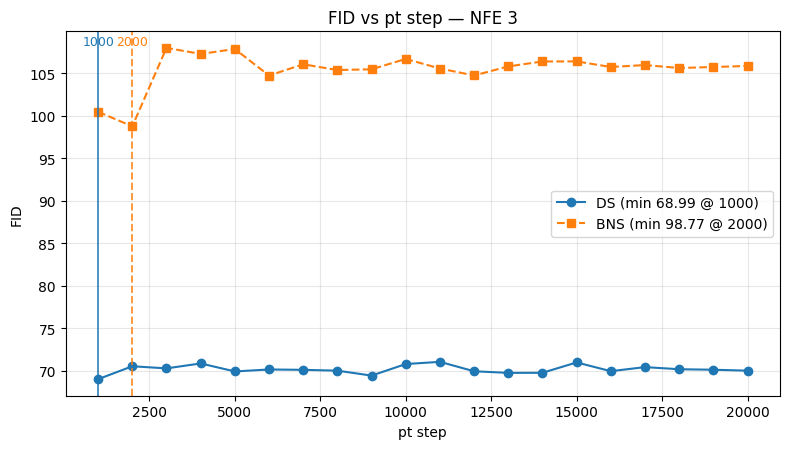

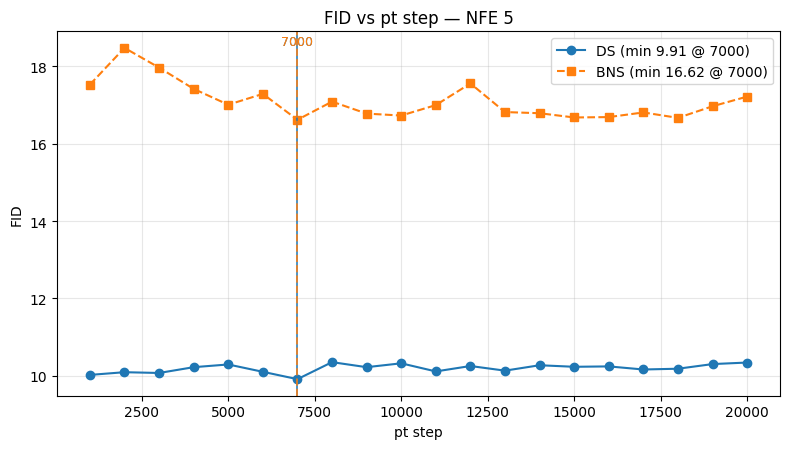

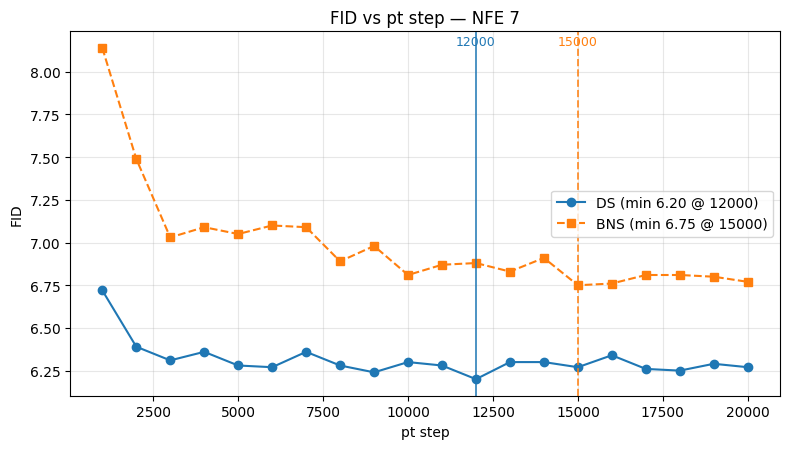

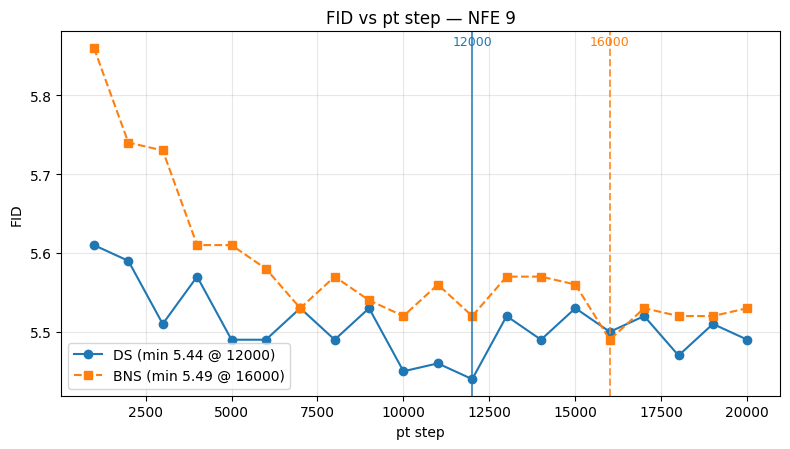

In [8]:
# Re-plot with vlines colored to match each model's curve.
import matplotlib.pyplot as plt
import numpy as np

steps = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000,
         11000, 12000, 13000, 14000, 15000, 16000, 17000, 18000, 19000, 20000]

ds = {
    3: [68.99, 70.51, 70.26, 70.84, 69.90, 70.13, 70.09, 69.99, 69.41, 70.77,
        71.03, 69.92, 69.73, 69.74, 70.96, 69.93, 70.41, 70.16, 70.10, 69.99],
    5: [10.02, 10.09, 10.07, 10.22, 10.29, 10.10,  9.91, 10.35, 10.22, 10.32,
        10.11, 10.25, 10.13, 10.27, 10.23, 10.24, 10.16, 10.18, 10.30, 10.34],
    7: [ 6.72,  6.39,  6.31,  6.36,  6.28,  6.27,  6.36,  6.28,  6.24,  6.30,
         6.28,  6.20,  6.30,  6.30,  6.27,  6.34,  6.26,  6.25,  6.29,  6.27],
    9: [ 5.61,  5.59,  5.51,  5.57,  5.49,  5.49,  5.53,  5.49,  5.53,  5.45,
         5.46,  5.44,  5.52,  5.49,  5.53,  5.50,  5.52,  5.47,  5.51,  5.49],
}

bns = {
    3: [100.48,  98.77, 108.01, 107.30, 107.88, 104.75, 106.08, 105.40, 105.49, 106.71,
        105.58, 104.76, 105.83, 106.41, 106.42, 105.76, 105.99, 105.64, 105.76, 105.88],
    5: [ 17.53,  18.48,  17.97,  17.42,  17.01,  17.29,  16.62,  17.09,  16.78,  16.73,
         17.00,  17.56,  16.82,  16.79,  16.68,  16.69,  16.81,  16.67,  16.97,  17.22],
    7: [  8.14,   7.49,   7.03,   7.09,   7.05,   7.10,   7.09,   6.89,   6.98,   6.81,
          6.87,   6.88,   6.83,   6.91,   6.75,   6.76,   6.81,   6.81,   6.80,   6.77],
    9: [  5.86,   5.74,   5.73,   5.61,   5.61,   5.58,   5.53,   5.57,   5.54,   5.52,
          5.56,   5.52,   5.57,   5.57,   5.56,   5.49,   5.53,   5.52,   5.52,   5.53],
}

def plot_with_colored_vlines(nfe):
    x = np.array(steps)
    y_ds = np.array(ds[nfe])
    y_bns = np.array(bns[nfe])

    i_ds  = int(np.argmin(y_ds))
    i_bns = int(np.argmin(y_bns))

    fig, ax = plt.subplots(figsize=(8,4.6))
    l1, = ax.plot(x, y_ds,  marker='o', linestyle='-',  label=f'DS (min {y_ds[i_ds]:.2f} @ {x[i_ds]})')
    l2, = ax.plot(x, y_bns, marker='s', linestyle='--', label=f'BNS (min {y_bns[i_bns]:.2f} @ {x[i_bns]})')

    # vlines colored to match the corresponding line
    ax.axvline(x[i_ds],  linestyle='-',  linewidth=1.4, alpha=0.8, color=l1.get_color())
    ax.axvline(x[i_bns], linestyle='--', linewidth=1.4, alpha=0.8, color=l2.get_color())

    # annotate using matching colors
    ymax = max(y_ds.max(), y_bns.max())
    ax.text(x[i_ds],  ymax, f'{x[i_ds]}', ha='center', va='bottom', fontsize=9, color=l1.get_color())
    ax.text(x[i_bns], ymax, f'{x[i_bns]}', ha='center', va='bottom', fontsize=9, color=l2.get_color())

    ax.set_xlabel("pt step")
    ax.set_ylabel("FID")
    ax.set_title(f"FID vs pt step — NFE {nfe}")
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    plt.show()

for nfe in [3,5,7,9]:
    plot_with_colored_vlines(nfe)



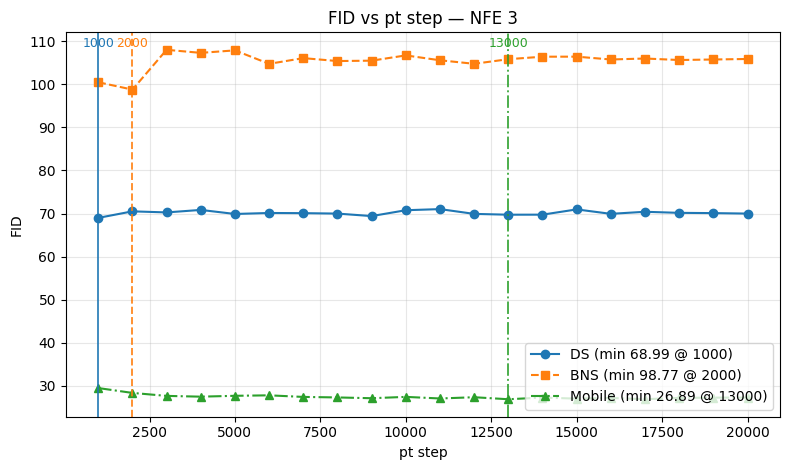

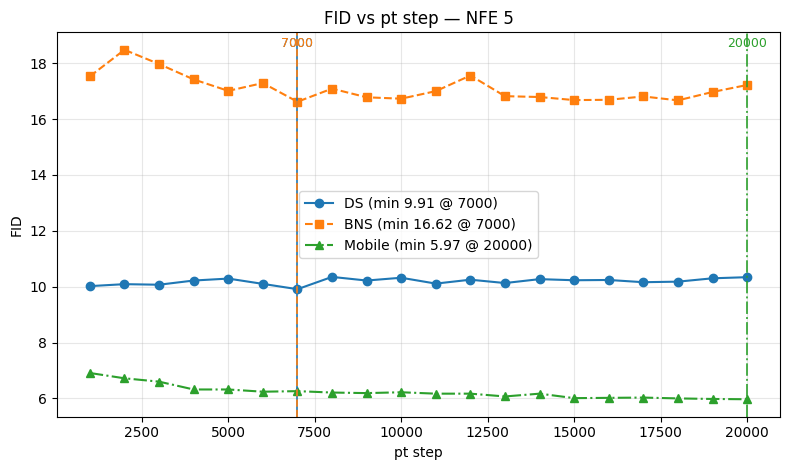

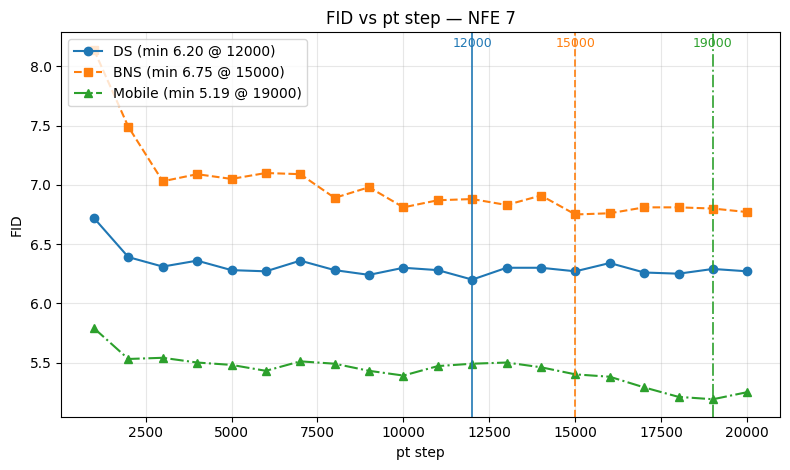

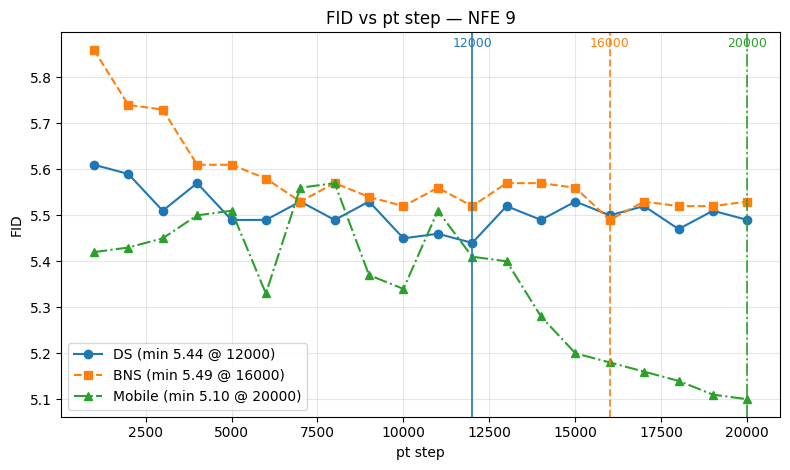

In [8]:
# Fix format specifiers for f-strings (use :.2f inside {} only for floats).

import matplotlib.pyplot as plt
import numpy as np

steps = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000,
         11000, 12000, 13000, 14000, 15000, 16000, 17000, 18000, 19000, 20000]

ds = {
    3: [68.99, 70.51, 70.26, 70.84, 69.90, 70.13, 70.09, 69.99, 69.41, 70.77,
        71.03, 69.92, 69.73, 69.74, 70.96, 69.93, 70.41, 70.16, 70.10, 69.99],
    5: [10.02, 10.09, 10.07, 10.22, 10.29, 10.10,  9.91, 10.35, 10.22, 10.32,
        10.11, 10.25, 10.13, 10.27, 10.23, 10.24, 10.16, 10.18, 10.30, 10.34],
    7: [ 6.72,  6.39,  6.31,  6.36,  6.28,  6.27,  6.36,  6.28,  6.24,  6.30,
         6.28,  6.20,  6.30,  6.30,  6.27,  6.34,  6.26,  6.25,  6.29,  6.27],
    9: [ 5.61,  5.59,  5.51,  5.57,  5.49,  5.49,  5.53,  5.49,  5.53,  5.45,
         5.46,  5.44,  5.52,  5.49,  5.53,  5.50,  5.52,  5.47,  5.51,  5.49],
}

bns = {
    3: [100.48,  98.77, 108.01, 107.30, 107.88, 104.75, 106.08, 105.40, 105.49, 106.71,
        105.58, 104.76, 105.83, 106.41, 106.42, 105.76, 105.99, 105.64, 105.76, 105.88],
    5: [ 17.53,  18.48,  17.97,  17.42,  17.01,  17.29,  16.62,  17.09,  16.78,  16.73,
         17.00,  17.56,  16.82,  16.79,  16.68,  16.69,  16.81,  16.67,  16.97,  17.22],
    7: [  8.14,   7.49,   7.03,   7.09,   7.05,   7.10,   7.09,   6.89,   6.98,   6.81,
          6.87,   6.88,   6.83,   6.91,   6.75,   6.76,   6.81,   6.81,   6.80,   6.77],
    9: [  5.86,   5.74,   5.73,   5.61,   5.61,   5.58,   5.53,   5.57,   5.54,   5.52,
          5.56,   5.52,   5.57,   5.57,   5.56,   5.49,   5.53,   5.52,   5.52,   5.53],
}

mobile = {
    3: [29.49, 28.36, 27.67, 27.49, 27.69, 27.80, 27.43, 27.31, 27.13, 27.44,
        27.07, 27.36, 26.89, 27.29, 27.03, 27.18, 26.91, 27.19, 27.27, 27.27],
    5: [ 6.91,  6.72,  6.60,  6.32,  6.32,  6.24,  6.26,  6.21,  6.19,  6.22,
          6.17,  6.17,  6.07,  6.17,  6.01,  6.02,  6.03,  6.00,  5.98,  5.97],
    7: [ 5.79,  5.53,  5.54,  5.50,  5.48,  5.43,  5.51,  5.49,  5.43,  5.39,
          5.47,  5.49,  5.50,  5.46,  5.40,  5.38,  5.29,  5.21,  5.19,  5.25],
    9: [ 5.42,  5.43,  5.45,  5.50,  5.51,  5.33,  5.56,  5.57,  5.37,  5.34,
          5.51,  5.41,  5.40,  5.28,  5.20,  5.18,  5.16,  5.14,  5.11,  5.10],
}

def plot_with_colored_vlines(nfe):
    x = np.array(steps)
    y_ds = np.array(ds[nfe], dtype=float)
    y_bns = np.array(bns[nfe], dtype=float)
    y_mo = np.array(mobile[nfe], dtype=float)

    i_ds  = int(np.argmin(y_ds))
    i_bns = int(np.argmin(y_bns))
    i_mo  = int(np.argmin(y_mo))

    fig, ax = plt.subplots(figsize=(8,4.8))
    l1, = ax.plot(x, y_ds,  marker='o', linestyle='-',  label=f'DS (min {y_ds[i_ds]:.2f} @ {x[i_ds]})')
    l2, = ax.plot(x, y_bns, marker='s', linestyle='--', label=f'BNS (min {y_bns[i_bns]:.2f} @ {x[i_bns]})')
    l3, = ax.plot(x, y_mo,  marker='^', linestyle='-.', label=f'Mobile (min {y_mo[i_mo]:.2f} @ {x[i_mo]})')

    ax.axvline(x[i_ds],  linestyle='-',  linewidth=1.4, alpha=0.85, color=l1.get_color())
    ax.axvline(x[i_bns], linestyle='--', linewidth=1.4, alpha=0.85, color=l2.get_color())
    ax.axvline(x[i_mo],  linestyle='-.', linewidth=1.4, alpha=0.85, color=l3.get_color())

    ymax = max(y_ds.max(), y_bns.max(), y_mo.max())
    ax.text(x[i_ds],  ymax, f'{x[i_ds]}', ha='center', va='bottom', fontsize=9, color=l1.get_color())
    ax.text(x[i_bns], ymax, f'{x[i_bns]}', ha='center', va='bottom', fontsize=9, color=l2.get_color())
    ax.text(x[i_mo],  ymax, f'{x[i_mo]}',  ha='center', va='bottom', fontsize=9, color=l3.get_color())

    ax.set_xlabel("pt step")
    ax.set_ylabel("FID")
    ax.set_title(f"FID vs pt step — NFE {nfe}")
    
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    plt.show()

for nfe in [3,5,7,9]:
    plot_with_colored_vlines(nfe)
